In [63]:
# seaborn module
!pip install seaborn --upgrade


In [64]:
# this module is to do advance mathmatical calculation 
# just like numpy and pandas does but this works as pro
!pip install scipy


In [65]:
from pycaret.classification import * 
# all other important libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns

In [66]:
v = pd.read_csv("HeartFailureDataset.csv")

In [67]:
v.head(1)

,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
0,0,18393,2,168,62,110,80,1,1,0,0,1,0


In [68]:

v['age_years'] = v['age'] / 365

v['age_years'] = v['age_years'].round(0)


In [69]:
v = v.drop(["id" , "age"] , axis = 1)

In [70]:
v.corr()
# correlations within columns and columns to outputs

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
gender,1.000000,0.499033,0.155412,0.006003,0.015254,-0.035821,-0.020491,0.338135,0.170966,0.005866,0.008109,-0.023017
height,0.499033,1.000000,0.290966,0.005484,0.006150,-0.050226,-0.018595,0.187989,0.094419,-0.006570,-0.010821,-0.081456
weight,0.155412,0.290966,1.000000,0.030701,0.043711,0.141763,0.106859,0.067779,0.067115,-0.016865,0.181656,0.053659
ap_hi,0.006003,0.005484,0.030701,1.000000,0.016085,0.023776,0.011840,-0.000923,0.001408,-0.000039,0.054472,0.020791
ap_lo,0.015254,0.006150,0.043711,0.016085,1.000000,0.024019,0.010806,0.005186,0.010601,0.004780,0.065719,0.017754
cholesterol,-0.035821,-0.050226,0.141763,0.023776,0.024019,1.000000,0.451578,0.010354,0.035760,0.009911,0.221147,0.154386
gluc,-0.020491,-0.018595,0.106859,0.011840,0.010806,0.451578,1.000000,-0.004756,0.011246,-0.006770,0.089307,0.098596
smoke,0.338135,0.187989,0.067779,-0.000923,0.005186,0.010354,-0.004756,1.000000,0.340094,0.025858,-0.015486,-0.047884
alco,0.170966,0.094419,0.067115,0.001408,0.010601,0.035760,0.011246,0.340094,1.000000,0.025476,-0.007330,-0.029918
active,0.005866,-0.006570,-0.016865,-0.000039,0.004780,0.009911,-0.006770,0.025858,0.025476,1.000000,-0.035653,-0.009819


In [71]:
v.isnull().sum()
# no any  null values we  found


gender         0
height         0
weight         0
ap_hi          0
ap_lo          0
cholesterol    0
gluc           0
smoke          0
alco           0
active         0
cardio         0
age_years      0
dtype: int64

In [72]:
v.duplicated().sum()

# we have 3820 duplicated values
# lets removes it .


3820

In [73]:
# removing duplicates rows 
v = v.drop_duplicates()


In [74]:
v.duplicated().sum()
# there is no any duplicate values 

0

In [75]:
v.describe()

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
count,66180.000000,66180.000000,66180.000000,66180.000000,66180.000000,66180.000000,66180.000000,66180.000000,66180.000000,66180.000000,66180.000000,66180.000000
mean,1.357238,164.345346,74.578906,129.305500,97.608099,1.386008,1.238184,0.092762,0.056754,0.797613,0.513629,53.365292
std,0.479189,8.353827,14.613633,158.372891,193.788349,0.692243,0.584152,0.290101,0.231374,0.401783,0.499818,6.807712
min,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000,30.000000
25%,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000,48.000000
50%,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,1.000000,54.000000
75%,2.000000,170.000000,83.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000,59.000000
max,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000,65.000000


In [88]:
v['cardio'].value_counts(normalize=True)*100
# almost balanced dataset 

cardio
1    51.36295
0    48.63705
Name: proportion, dtype: float64

In [99]:
v['cardio'].value_counts()

cardio
1    33992
0    32188
Name: count, dtype: int64

In [76]:
corr = v.corr()  

<Axes: >

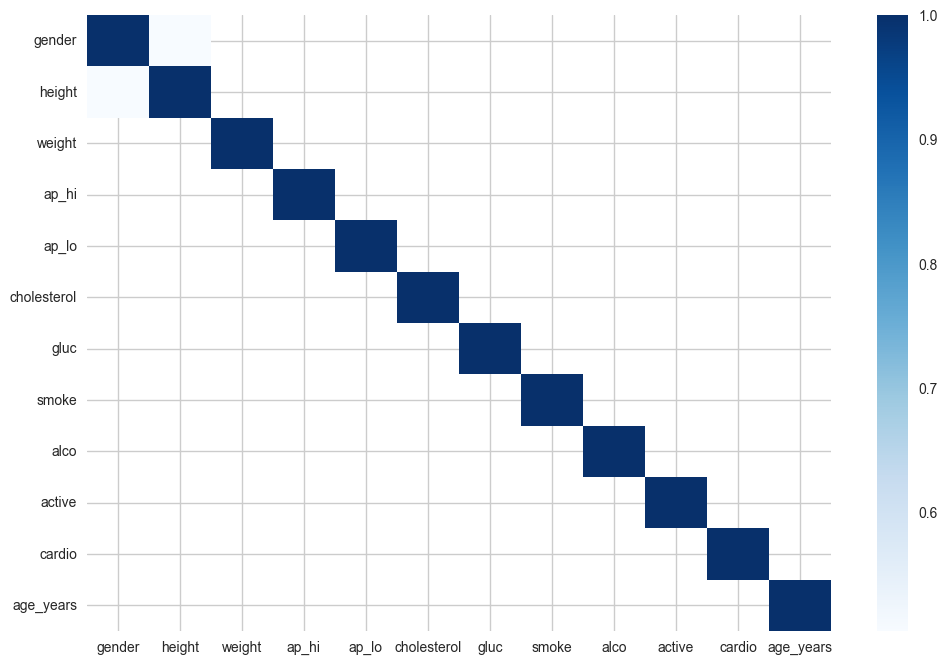

In [82]:
kot = corr[corr >= 0.45]
plt.figure(figsize=(12,8))
sns.heatmap(kot, cmap="Blues")

# by this we can see gender and height   have good correlation 
# so what we will do is to  merde  in single columnn and  will be naming 
# as bmi.

# Pycaret

Pycaret is an open-source machine learning library for Python that provides a user-friendly interface for building and deploying machine learning models. It offers a range of features,including data preprocessing, feature engineering, model selection, and hyperparameter tuning. Pycaret also provides tools for model interpretation and explanation, making it easier to understand how a model is making predictions. Overall, Pycaret is a powerful and accessible tool for data scientists and machine learning practitioners.

In [89]:
clf = setup(data=v, 
            target='cardio', # to tell pycaret what is our target 
            session_id=123, # equivlent to random_state
            normalize=True , # to scale 
            categorical_features=['gender','cholesterol','gluc' ,'smoke','alco','active'])
                       # to  reminding to pycarot that is  c         

,Description,Value
0,Session id,123
1,Target,cardio
2,Target type,Binary
3,Original data shape,"(66180, 12)"
4,Transformed data shape,"(66180, 16)"
5,Transformed train set shape,"(46326, 16)"
6,Transformed test set shape,"(19854, 16)"
7,Numeric features,5
8,Categorical features,6
9,Preprocess,True


In [79]:
v.head(2)

,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio,age_years
0,2,168,62,110,80,1,1,0,0,1,0,50.0
1,1,156,85,140,90,3,1,0,0,1,1,55.0


In [92]:
best = compare_models()
# by  this pycaret will train my models
# by  almost every important technique
# and will give the best result. 

,Model,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC,TT (Sec)
lightgbm,Light Gradient Boosting Machine,0.7330,0.8007,0.7117,0.7546,0.7325,0.4665,0.4673,0.2010
gbc,Gradient Boosting Classifier,0.7329,0.8010,0.7123,0.7541,0.7326,0.4663,0.4671,0.4480
catboost,CatBoost Classifier,0.7321,0.8006,0.7120,0.7530,0.7319,0.4646,0.4653,4.3100
xgboost,Extreme Gradient Boosting,0.7294,0.7960,0.7088,0.7505,0.7290,0.4592,0.4600,0.3210
ada,Ada Boost Classifier,0.7271,0.7937,0.6792,0.7636,0.7188,0.4555,0.4586,0.2190
lr,Logistic Regression,0.7206,0.7852,0.7023,0.7404,0.7208,0.4415,0.4422,1.3370
rf,Random Forest Classifier,0.6926,0.7486,0.7014,0.7006,0.7010,0.3847,0.3848,0.6600
knn,K Neighbors Classifier,0.6785,0.7278,0.6770,0.6909,0.6838,0.3569,0.3570,0.5180
et,Extra Trees Classifier,0.6783,0.7134,0.6958,0.6836,0.6896,0.3558,0.3559,0.7150
ridge,Ridge Classifier,0.6439,0.7000,0.6448,0.6561,0.6504,0.2876,0.2877,0.0640


In [93]:

print(best) 


LGBMClassifier(boosting_type='gbdt', class_weight=None, colsample_bytree=1.0,
               importance_type='split', learning_rate=0.1, max_depth=-1,
               min_child_samples=20, min_child_weight=0.001, min_split_gain=0.0,
               n_estimators=100, n_jobs=-1, num_leaves=31, objective=None,
               random_state=123, reg_alpha=0.0, reg_lambda=0.0, subsample=1.0,
               subsample_for_bin=200000, subsample_freq=0)


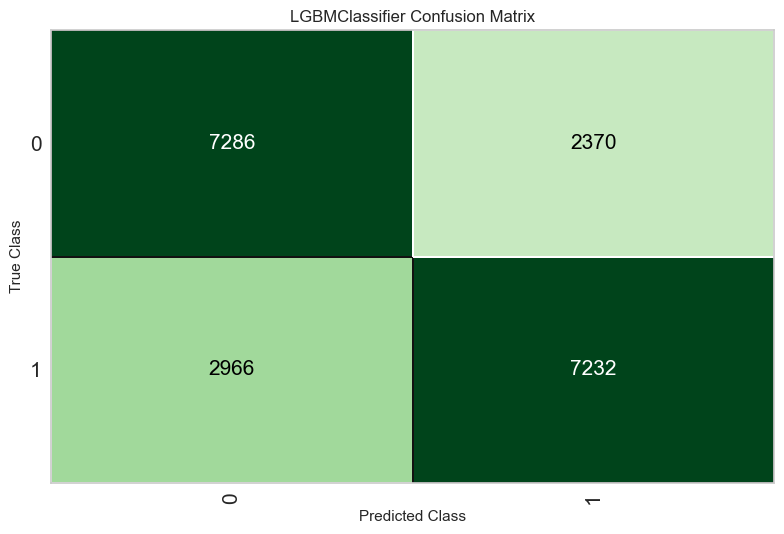

In [96]:

plot_model(best, plot = 'confusion_matrix')

#  lgbm classifier confusion matrix  lgbm classifier :  
      what does it say  :  what does it say 


In [ ]:

                 
model predicted that 7232 people have heart disease (1)
and they really have (1) that  is known as True positive (1,1)


model predicted that 2966 people  dont have heart disease (0)
but they have(1) .that  is known as False negative (1,0)


model predicted that 7286 peoples dont have  heart disease (0)
and they really doant have(0)that  is known as  True neagtive (0,0) 


model predicted that 2370 people have heart disease (1)
but they really dont  have heart disease that is  known as false positive  (0,1)






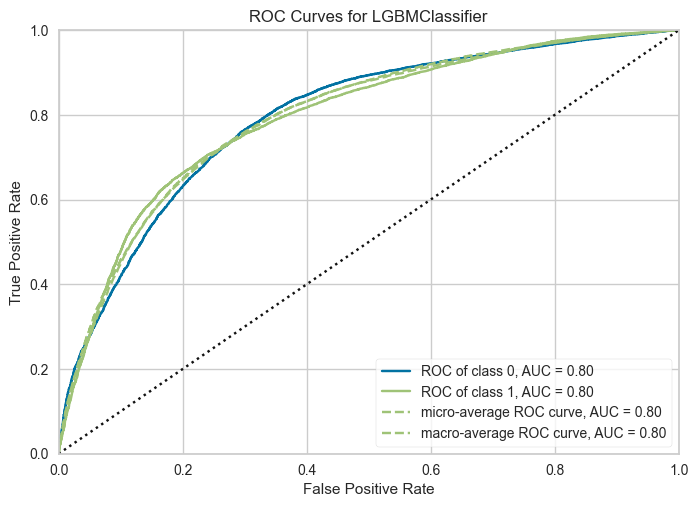

In [100]:
plot_model(best, plot='auc')

 # means the sepration power of classes is 80 percent.

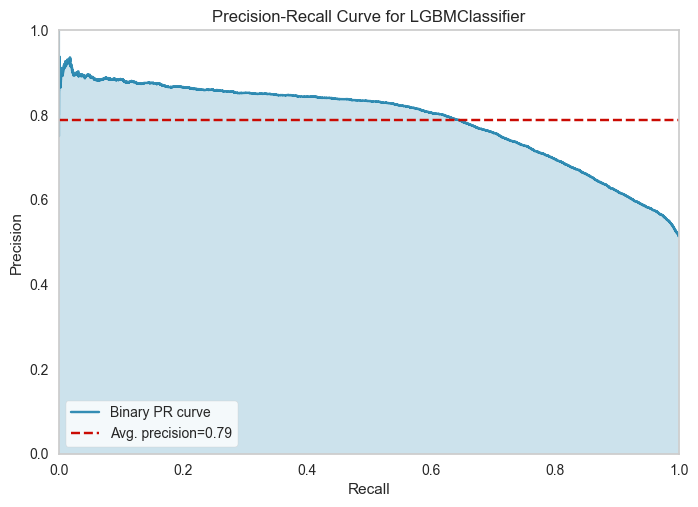

In [101]:
plot_model(best, plot='pr') 
# can see our average precion is 79 
# recall is 71.

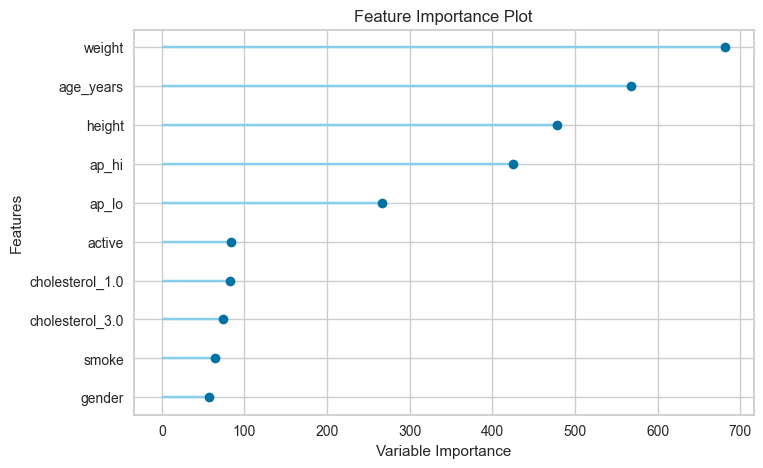

In [108]:
plot_model(best, plot='feature')      
# we can see that weight age height is an important
# feature to understand the pattern for model .

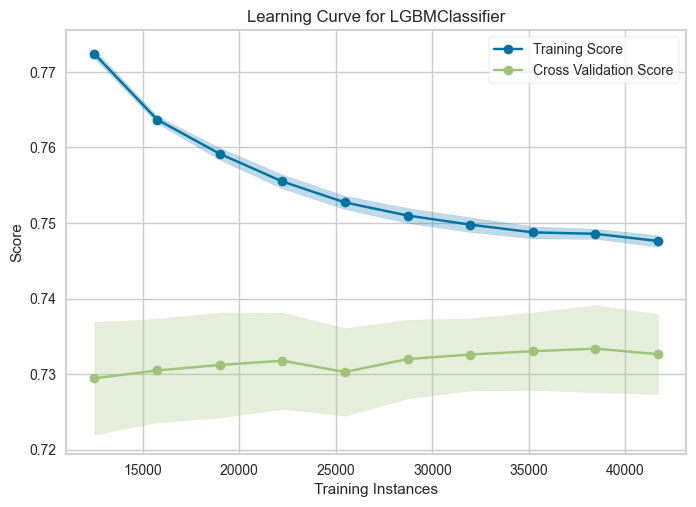

In [112]:
plot_model(best, plot='learning') 
# can see the learning ciurve of my model 

In [114]:
lightgbm = create_model('lightgbm') 

# here folds  0 to 10 folds means ..
# means by my machine our data was devided 
# into 10 parts ..and for first  it have  limited data 
# that is trained  by my model and evaluate the 
# accuracy matrices ..same for others parts or folks of  data too
# then my machine took an  average performance 

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7261,0.7909,0.7202,0.7397,0.7298,0.4522,0.4524
1,0.7360,0.8099,0.7101,0.7602,0.7343,0.4726,0.4737
2,0.7349,0.7965,0.7105,0.7583,0.7336,0.4704,0.4714
3,0.7352,0.8046,0.7134,0.7570,0.7346,0.4708,0.4716
4,0.7220,0.7928,0.6961,0.7456,0.7200,0.4446,0.4456
5,0.7354,0.8012,0.7272,0.7499,0.7384,0.4708,0.4710
6,0.7345,0.8004,0.7045,0.7608,0.7316,0.4696,0.4710
7,0.7271,0.7917,0.7020,0.7506,0.7255,0.4548,0.4558
8,0.7375,0.8074,0.7158,0.7593,0.7369,0.4754,0.4762


In [115]:
tuned_model= tune_model(lightgbm)

,Accuracy,AUC,Recall,Prec.,F1,Kappa,MCC
Fold,,,,,,,
0,0.7259,0.7907,0.7202,0.7394,0.7297,0.4517,0.4519
1,0.7343,0.8095,0.7134,0.7557,0.7340,0.4690,0.4698
2,0.7330,0.7987,0.7218,0.7492,0.7353,0.4662,0.4665
3,0.7356,0.8044,0.7193,0.7545,0.7365,0.4715,0.4720
4,0.7237,0.7925,0.7037,0.7443,0.7234,0.4479,0.4486
5,0.7356,0.8017,0.7280,0.7498,0.7388,0.4712,0.4714
6,0.7323,0.8002,0.7095,0.7546,0.7314,0.4651,0.4660
7,0.7258,0.7925,0.7066,0.7461,0.7258,0.4520,0.4527
8,0.7381,0.8086,0.7179,0.7591,0.7380,0.4767,0.4774


Fitting 10 folds for each of 10 candidates, totalling 100 fits
Original model was better than the tuned model, hence it will be returned. NOTE: The display metrics are for the tuned model (not the original one).
